In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [6]:
df=pd.read_csv(r'C:\Users\k9481\OneDrive\Documents\ml databases\heart.csv')


In [7]:
df

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1020,59,1,1,140,221,0,1,164,1,0.0,2,0,2,1
1021,60,1,0,125,258,0,0,141,1,2.8,1,1,3,0
1022,47,1,0,110,275,0,0,118,1,1.0,1,1,2,0
1023,50,0,0,110,254,0,0,159,0,0.0,2,0,2,1


In [8]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [9]:
from sklearn.tree import DecisionTreeClassifier,plot_tree
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [11]:
df.shape

(1025, 14)

In [12]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


In [19]:
df.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

In [18]:
df['target'].value_counts()

target
1    526
0    499
Name: count, dtype: int64

age          Age of patient
sex          0 = Female, 1 = Male
cp           Chest pain type (0-3)
trestbps     Resting blood pressure
chol         Cholesterol level
thalach      Maximum heart rate
target       0 = No disease, 1 = Has disease

In [23]:
df.dtypes

age           int64
sex           int64
cp            int64
trestbps      int64
chol          int64
fbs           int64
restecg       int64
thalach       int64
exang         int64
oldpeak     float64
slope         int64
ca            int64
thal          int64
target        int64
dtype: object

In [24]:
X=df.drop('target',axis=1)
y=df['target']

In [25]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

In [27]:
X_train.shape


(820, 13)

In [28]:
X_test.shape



(205, 13)

In [30]:
model=DecisionTreeClassifier(
    criterion='gini',
    max_depth=4,
    random_state=42
)
model.fit(X_train,y_train)

DecisionTreeClassifier(max_depth=4, random_state=42)

In [31]:
y_pred = model.predict(X_test)

print("Accuracy :", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy : 0.8390243902439024

Classification Report:
               precision    recall  f1-score   support

           0       0.86      0.80      0.83       100
           1       0.82      0.88      0.85       105

    accuracy                           0.84       205
   macro avg       0.84      0.84      0.84       205
weighted avg       0.84      0.84      0.84       205


Confusion Matrix:
 [[80 20]
 [13 92]]


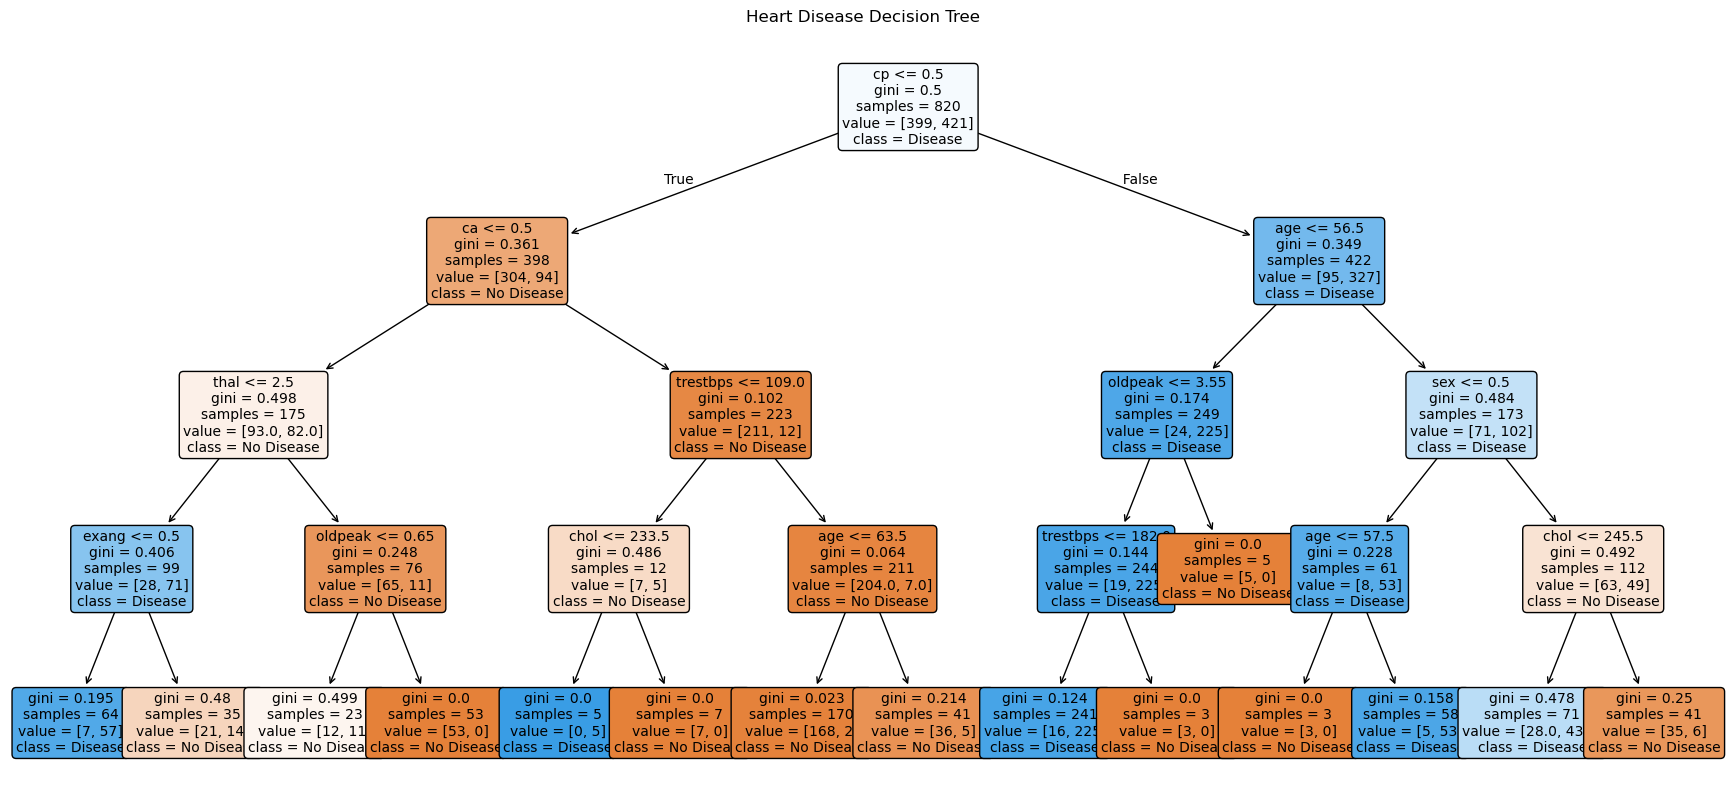

In [32]:
plt.figure(figsize=(22, 10))
plot_tree(
    model,
    feature_names=X.columns.tolist(),
    class_names=['No Disease', 'Disease'],
    filled=True,
    rounded=True,
    fontsize=10
)
plt.title("Heart Disease Decision Tree")
plt.show()

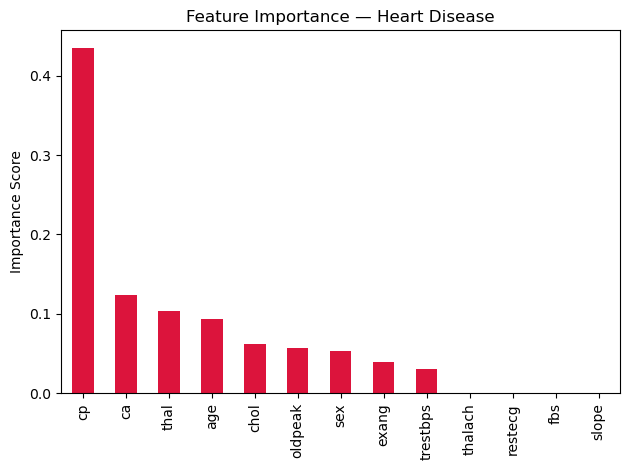

cp          0.435373
ca          0.123549
thal        0.103193
age         0.094111
chol        0.061523
oldpeak     0.057389
sex         0.053821
exang       0.039893
trestbps    0.031148
thalach     0.000000
restecg     0.000000
fbs         0.000000
slope       0.000000
dtype: float64


In [33]:
importance = pd.Series(
    model.feature_importances_,
    index=X.columns.tolist()
)

importance.sort_values(ascending=False).plot(kind='bar', color='crimson')
plt.title("Feature Importance — Heart Disease")
plt.ylabel("Importance Score")
plt.tight_layout()
plt.show()

print(importance.sort_values(ascending=False))

In [34]:
# Overfitting check
train_acc = accuracy_score(y_train, model.predict(X_train))
test_acc  = accuracy_score(y_test, y_pred)

print(f"Train Accuracy : {train_acc:.2f}")
print(f"Test Accuracy  : {test_acc:.2f}")
print(f"Gap            : {train_acc - test_acc:.2f}")

print()

# Best depth loop
for depth in range(1, 11):
    m = DecisionTreeClassifier(max_depth=depth, random_state=42)
    m.fit(X_train, y_train)
    train_a = accuracy_score(y_train, m.predict(X_train))
    test_a  = accuracy_score(y_test, m.predict(X_test))
    print(f"Depth {depth:2d} → Train: {train_a:.2f}  Test: {test_a:.2f}")
    

Train Accuracy : 0.89
Test Accuracy  : 0.84
Gap            : 0.05

Depth  1 → Train: 0.77  Test: 0.72
Depth  2 → Train: 0.77  Test: 0.72
Depth  3 → Train: 0.85  Test: 0.85
Depth  4 → Train: 0.89  Test: 0.84
Depth  5 → Train: 0.93  Test: 0.87
Depth  6 → Train: 0.97  Test: 0.92
Depth  7 → Train: 0.99  Test: 0.95
Depth  8 → Train: 1.00  Test: 0.98
Depth  9 → Train: 1.00  Test: 0.99
Depth 10 → Train: 1.00  Test: 0.99


Depth  1 → Train: 0.77  Test: 0.72  ← Underfitting (too simple)
Depth  2 → Train: 0.77  Test: 0.72  ← Still underfitting
Depth  3 → Train: 0.85  Test: 0.85  ← Good fit, train ≈ test ✅<--------------------------------------good place
Depth  4 → Train: 0.89  Test: 0.84  ← Still decent
Depth  5 → Train: 0.93  Test: 0.87  ← Gap starting to grow ⚠️
Depth  6 → Train: 0.97  Test: 0.92  ← Overfitting beginning
Depth  7 → Train: 0.99  Test: 0.95  ← Clear overfitting ❌
Depth  8 → Train: 1.00  Test: 0.98  ← Memorizing training data
Depth  9 → Train: 1.00  Test: 0.99  ← Fully memorized
Depth 10 → Train: 1.00  Test: 0.99  ← No improvement

In [35]:
# [age, sex, cp, trestbps, chol, fbs, restecg, thalach, exang, oldpeak, slope, ca, thal]
new_patient = [[52, 1, 0, 125, 212, 0, 1, 168, 0, 1.0, 2, 2, 3]]

result = model.predict(new_patient)
prob   = model.predict_proba(new_patient)

print("Heart Disease?  :", "Yes" if result[0] == 1 else "No")
print("Probability     :", round(prob[0][1] * 100, 2), "%")

Heart Disease?  : No
Probability     : 1.18 %


C:\Users\k9481\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
C:\Users\k9481\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
